# Actividad 2: Introducción al Perceptrón Multicapa

> **Reto:** ¿Cómo construir y entrenar una red neuronal para datos estructurados?

En esta actividad construimos y entrenamos un **Perceptrón Multicapa (MLP)** utilizando **Keras** (sobre TensorFlow) para resolver el mismo problema de clasificación de tumores de mama de la Actividad 1, aplicando técnicas de **regularización para evitar el sobreajuste** y evaluando el desempeño de forma objetiva.

## Contenidos
1. [Fundamentos del Perceptrón Multicapa](#1-fundamentos-del-perceptrón-multicapa)
2. [Preparación del entorno](#2-preparación-del-entorno)
3. [Carga y preprocesamiento del dataset](#3-carga-y-preprocesamiento-del-dataset)
4. [Construcción del MLP base con Keras](#4-construcción-del-mlp-base-con-keras)
5. [Técnicas para evitar el sobreajuste](#5-técnicas-para-evitar-el-sobreajuste)
6. [Entrenamiento y curvas de aprendizaje](#6-entrenamiento-y-curvas-de-aprendizaje)
7. [Evaluación objetiva con métricas](#7-evaluación-objetiva-con-métricas)
8. [Comparación de arquitecturas](#8-comparación-de-arquitecturas)
9. [Conclusiones](#9-conclusiones)


## 1. Fundamentos del Perceptrón Multicapa

### ¿Qué es un MLP?

Un **Perceptrón Multicapa** es una red neuronal **feedforward** compuesta por:
- **Capa de entrada:** recibe las características del dataset.
- **Capas ocultas:** aplican transformaciones no lineales mediante funciones de activación (ReLU, tanh, etc.).
- **Capa de salida:** produce la predicción (sigmoide para clasificación binaria, softmax para multi-clase).

Cada neurona en una capa oculta $l$ computa:

$$a^{(l)} = g(W^{(l)} \cdot a^{(l-1)} + b^{(l)})$$

Donde $g$ es la función de activación, $W$ la matriz de pesos y $b$ el vector de sesgo.

### El problema del sobreajuste en MLP

Por su alta capacidad expresiva, los MLP pueden **memorizar** en lugar de **generalizar**. Señales de sobreajuste:
- Loss de entrenamiento sigue bajando mientras que la loss de validación **sube**.
- Diferencia grande entre accuracy de train y test.

### Estrategias de regularización que aplicaremos

| Técnica | Mecanismo | Efecto |
|---------|-----------|--------|
| **Dropout** | Apaga aleatoriamente neuronas durante el entrenamiento | Fuerza redundancia, evita co-adaptación |
| **Early Stopping** | Detiene el entrenamiento cuando la loss de validación deja de mejorar | Evita que el modelo siga memorizando |
| **Regularización L2** | Penaliza pesos grandes en la función de pérdida | Simplifica la frontera de decisión |
| **Batch Normalization** | Normaliza las activaciones entre capas | Estabiliza y acelera el entrenamiento |


## 2. Preparación del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Configuración y semillas
sns.set_theme(style='whitegrid', palette='viridis')
alt.renderers.enable('default')

np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow: {tf.__version__}')
print(f'Keras: {keras.__version__}')
print(f'GPU disponible: {tf.config.list_physical_devices("GPU")}')


TensorFlow: 2.21.0
Keras: 3.14.1
GPU disponible: []


## 3. Carga y preprocesamiento del dataset

Usamos el mismo dataset **Breast Cancer Wisconsin** de la Actividad 1, lo que nos permite comparar directamente: **SVM con kernel** vs **MLP con Keras**. Dataset limpio, 30 características numéricas, sin valores faltantes — foco total en la arquitectura de la red.


In [2]:
# Carga del dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print(f'Dimensiones: {X.shape}')
print(f'Clases: {data.target_names}')
print(f'Balance: {np.bincount(y)} ({np.bincount(y)/len(y)*100})')

# Train/Validation/Test split (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f'\nTrain: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}')

# Escalado (esencial para redes neuronales)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)


Dimensiones: (569, 30)
Clases: ['malignant' 'benign']
Balance: [212 357] ([37.25834798 62.74165202])

Train: 341 | Validation: 114 | Test: 114


## 4. Construcción del MLP base con Keras

Comenzamos con un MLP de 3 capas ocultas usando la API **Sequential** de Keras. Esta arquitectura base **sin regularización** nos servirá como punto de referencia para medir el impacto de las técnicas anti-sobreajuste.

Arquitectura: `Input(30) -> Dense(64, ReLU) -> Dense(32, ReLU) -> Dense(16, ReLU) -> Dense(1, sigmoid)`


In [3]:
def build_mlp_base(input_dim=30):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu', name='hidden_1'),
        layers.Dense(32, activation='relu', name='hidden_2'),
        layers.Dense(16, activation='relu', name='hidden_3'),
        layers.Dense(1, activation='sigmoid', name='output')
    ], name='MLP_Base')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_base = build_mlp_base()
mlp_base.summary()


Model: "MLP_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Entrenamiento del MLP base (SIN regularización, como referencia)
history_base = mlp_base.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=200,
    batch_size=32,
    verbose=0
)

# Evaluación en test
y_pred_base = (mlp_base.predict(X_test_s, verbose=0) > 0.5).astype(int).ravel()
acc_base = accuracy_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)

print(f'MLP Base - Test Accuracy: {acc_base:.4f}')
print(f'MLP Base - Test F1: {f1_base:.4f}')


MLP Base - Test Accuracy: 0.9474
MLP Base - Test F1: 0.9571


## 5. Técnicas para evitar el sobreajuste

Ahora construimos un MLP **regularizado**: Dropout + L2 + EarlyStopping + BatchNormalization. Visualizaremos las curvas de entrenamiento para contrastar con el modelo base y demostrar el efecto de la regularización.


In [5]:
def build_mlp_regularized(input_dim=30, dropout_rate=0.3, l2_reg=0.001):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg), name='dense_1'),
        layers.BatchNormalization(name='bn_1'),
        layers.Dropout(dropout_rate, name='dropout_1'),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg), name='dense_2'),
        layers.BatchNormalization(name='bn_2'),
        layers.Dropout(dropout_rate, name='dropout_2'),
        layers.Dense(32, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg), name='dense_3'),
        layers.BatchNormalization(name='bn_3'),
        layers.Dropout(dropout_rate, name='dropout_3'),
        layers.Dense(1, activation='sigmoid', name='output')
    ], name='MLP_Regularizado')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Callbacks para evitar sobreajuste
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

mlp_reg = build_mlp_regularized()
mlp_reg.summary()


Model: "MLP_Regularizado"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,233 (59.50 KB)

 Trainable params: 14,785 (57.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
# Entrenamiento del MLP regularizado
history_reg = mlp_reg.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

print(f'\nEpochs ejecutadas: {len(history_reg.history["loss"])}')

# Evaluación
y_pred_reg = (mlp_reg.predict(X_test_s, verbose=0) > 0.5).astype(int).ravel()
acc_reg = accuracy_score(y_test, y_pred_reg)
f1_reg = f1_score(y_test, y_pred_reg)

print(f'MLP Regularizado - Test Accuracy: {acc_reg:.4f}')
print(f'MLP Regularizado - Test F1: {f1_reg:.4f}')



Epoch 72: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 82: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 82: early stopping
Restoring model weights from the end of the best epoch: 62.

Epochs ejecutadas: 82
MLP Regularizado - Test Accuracy: 0.9561
MLP Regularizado - Test F1: 0.9645


## 6. Entrenamiento y curvas de aprendizaje

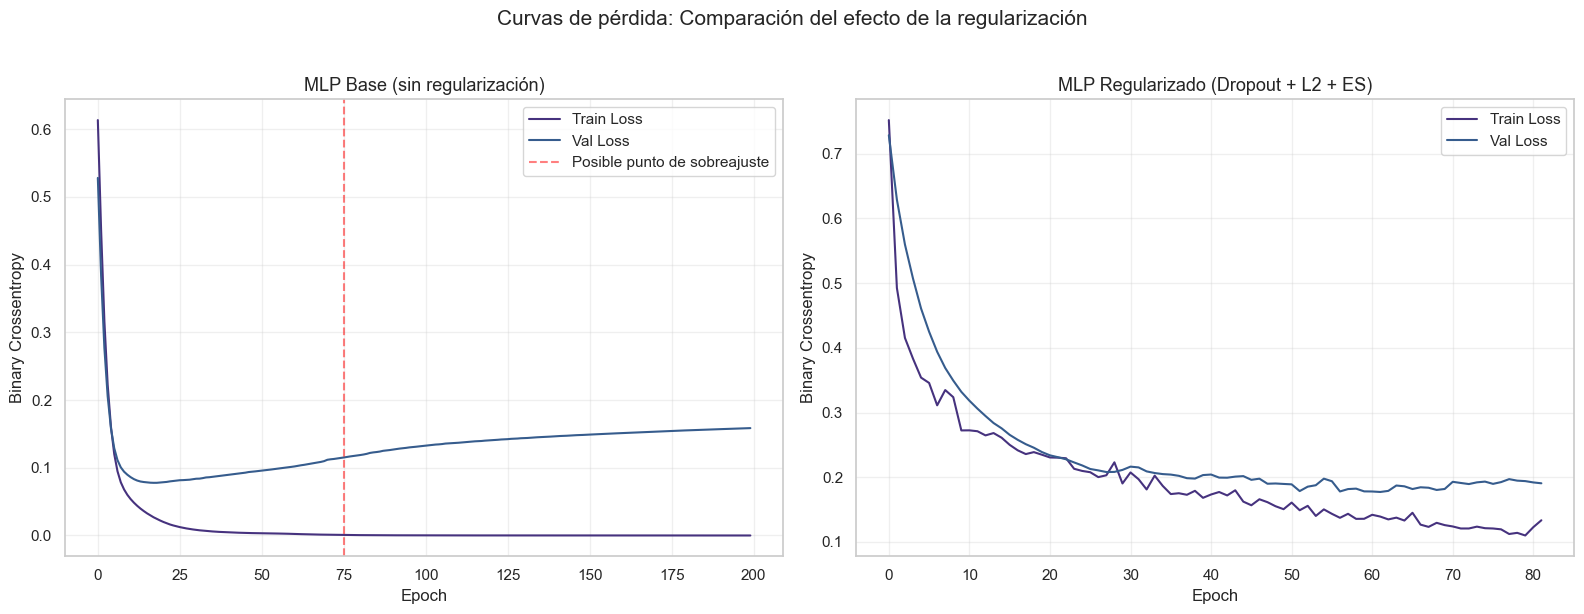

In [7]:
# Comparación visual de curvas de pérdida: Base vs Regularizado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Modelo Base
axes[0].plot(history_base.history['loss'], label='Train Loss', linewidth=1.5)
axes[0].plot(history_base.history['val_loss'], label='Val Loss', linewidth=1.5)
axes[0].axvline(x=75, color='red', linestyle='--', alpha=0.5, label='Posible punto de sobreajuste')
axes[0].set_title('MLP Base (sin regularización)', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Modelo Regularizado
axes[1].plot(history_reg.history['loss'], label='Train Loss', linewidth=1.5)
axes[1].plot(history_reg.history['val_loss'], label='Val Loss', linewidth=1.5)
axes[1].set_title('MLP Regularizado (Dropout + L2 + ES)', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Binary Crossentropy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de pérdida: Comparación del efecto de la regularización', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


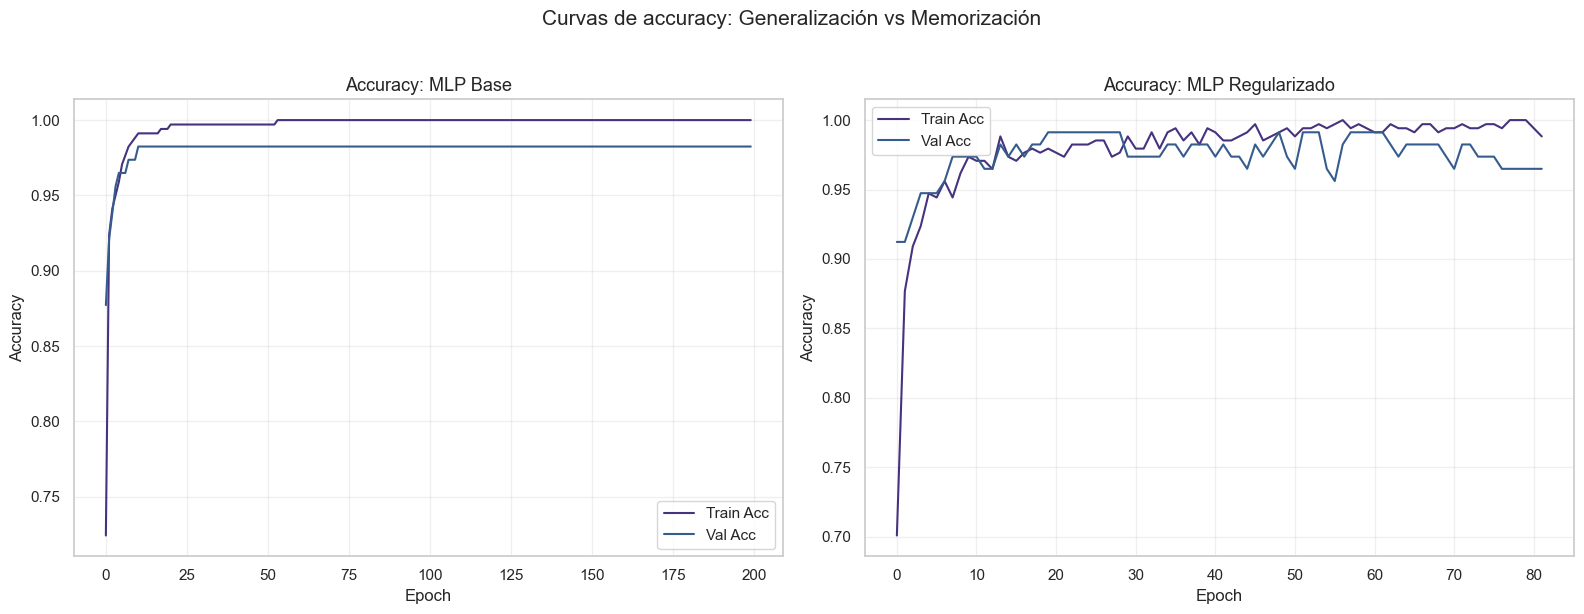

In [8]:
# Curvas de accuracy: Base vs Regularizado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(history_base.history['accuracy'], label='Train Acc', linewidth=1.5)
axes[0].plot(history_base.history['val_accuracy'], label='Val Acc', linewidth=1.5)
axes[0].set_title('Accuracy: MLP Base', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_reg.history['accuracy'], label='Train Acc', linewidth=1.5)
axes[1].plot(history_reg.history['val_accuracy'], label='Val Acc', linewidth=1.5)
axes[1].set_title('Accuracy: MLP Regularizado', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de accuracy: Generalización vs Memorización', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


## 7. Evaluación objetiva con métricas

Evaluamos ambos modelos con el conjunto de test usando **múltiples métricas** para una visión completa del desempeño, no solo accuracy.


In [9]:
# Evaluación comprensiva de ambos modelos
def evaluate_model(model, X_test, y_test, name):
    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).ravel()
    y_prob = model.predict(X_test, verbose=0).ravel()

    return {
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

results = [
    evaluate_model(mlp_base, X_test_s, y_test, 'MLP Base'),
    evaluate_model(mlp_reg, X_test_s, y_test, 'MLP Regularizado')
]

results_df = pd.DataFrame(results)
print('Tabla comparativa de métricas (conjunto de test):')
print(results_df.to_string(index=False))


Tabla comparativa de métricas (conjunto de test):
          Modelo  Accuracy  Precision   Recall  F1-Score  ROC-AUC
        MLP Base  0.947368   0.985294 0.930556  0.957143 0.990741
MLP Regularizado  0.956140   0.985507 0.944444  0.964539 0.995701


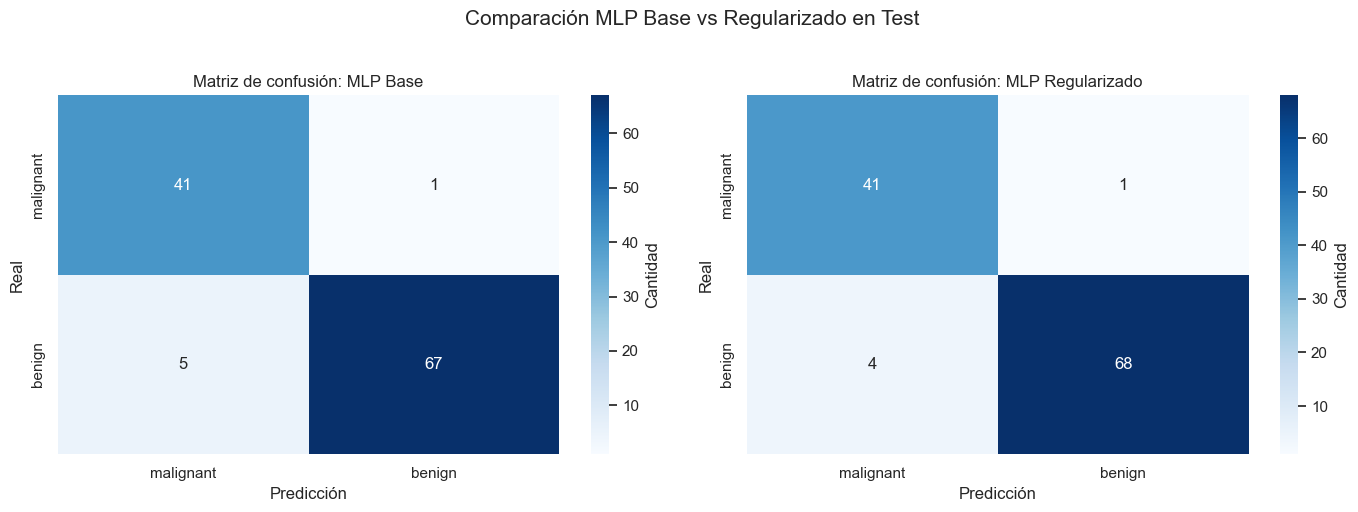

In [10]:
# Matrices de confusión comparativas con Seaborn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (model, name) in enumerate([
    (mlp_base, 'MLP Base'),
    (mlp_reg, 'MLP Regularizado')
]):
    y_pred = (model.predict(X_test_s, verbose=0) > 0.5).astype(int).ravel()
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=data.target_names, yticklabels=data.target_names,
                cbar_kws={'label': 'Cantidad'})
    axes[idx].set_title(f'Matriz de confusión: {name}', fontsize=12)
    axes[idx].set_xlabel('Predicción')
    axes[idx].set_ylabel('Real')

plt.suptitle('Comparación MLP Base vs Regularizado en Test', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


In [16]:
# Visualización interactiva con Altair: comparación de métricas
metrics_long = results_df.melt(id_vars=['Modelo'], var_name='Métrica', value_name='Valor')

chart = alt.Chart(metrics_long).mark_bar(cornerRadiusEnd=4).encode(
    x=alt.X('Modelo:N', title='Modelo'),
    y=alt.Y('Valor:Q', title='Valor', scale=alt.Scale(domain=[0.9, 1.0])),
    color=alt.Color('Modelo:N', legend=None, scale=alt.Scale(range=['#2E86AB', '#A23B72'])),
    column=alt.Column('Métrica:N', title='Métrica'),
    tooltip=['Modelo', 'Métrica', alt.Tooltip('Valor:Q', format='.4f')]
).properties(
    width=140,
    height=15
).configure_header(
    titleFontSize=12,
    labelFontSize=11
).configure_axis(
    labelFontSize=11,
    titleFontSize=12
)
chart



alt.Chart(...)

## 8. Comparación de arquitecturas

Exploramos cómo impacta la **capacidad de la red** (ancho y profundidad) en el desempeño, manteniendo siempre la regularización activa.


In [12]:
# Experimento: 4 arquitecturas con capacidad creciente
# Nombres válidos para Keras: solo letras, números, underscore, punto, slash, guion
configs = {
    'Pequena_32x16':       {'layers': [32, 16],            'l2': 0.0005, 'label': 'Pequeña (32-16)'},
    'Media_64x32x16':      {'layers': [64, 32, 16],        'l2': 0.001,  'label': 'Media (64-32-16)'},
    'Grande_128x64x32x16': {'layers': [128, 64, 32, 16],   'l2': 0.001,  'label': 'Grande (128-64-32-16)'},
    'Profunda_256x5':      {'layers': [256, 128, 64, 32, 16], 'l2': 0.001, 'label': 'Profunda (256-128-64-32-16)'}
}

arch_results = []

for name_key, cfg in configs.items():
    model = keras.Sequential(name=f'MLP_{name_key}')
    model.add(layers.Input(shape=(30,)))

    for units in cfg['layers']:
        model.add(layers.Dense(units, activation='relu',
                              kernel_regularizer=regularizers.l2(cfg['l2'])))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(0.3))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    es = EarlyStopping(monitor='val_loss', patience=15,
                       restore_best_weights=True, verbose=0)

    history = model.fit(
        X_train_s, y_train,
        validation_data=(X_val_s, y_val),
        epochs=200, batch_size=32,
        callbacks=[es], verbose=0
    )

    y_pred = (model.predict(X_test_s, verbose=0) > 0.5).astype(int).ravel()
    y_prob = model.predict(X_test_s, verbose=0).ravel()

    arch_results.append({
        'Arquitectura': cfg['label'],
        'Capas ocultas': len(cfg['layers']),
        'Neuronas totales': sum(cfg['layers']),
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Epochs ejecutadas': len(history.history['loss'])
    })

arch_df = pd.DataFrame(arch_results)
print('\nComparación de arquitecturas (todas con regularización):')
print(arch_df.to_string(index=False))



Comparación de arquitecturas (todas con regularización):
               Arquitectura  Capas ocultas  Neuronas totales  Accuracy  F1-Score  ROC-AUC  Epochs ejecutadas
            Pequeña (32-16)              2                48  0.964912  0.971831 0.995040                118
           Media (64-32-16)              3               112  0.964912  0.971831 0.997024                109
      Grande (128-64-32-16)              4               240  0.956140  0.964539 0.993717                 90
Profunda (256-128-64-32-16)              5               496  0.929825  0.942029 0.994378                122


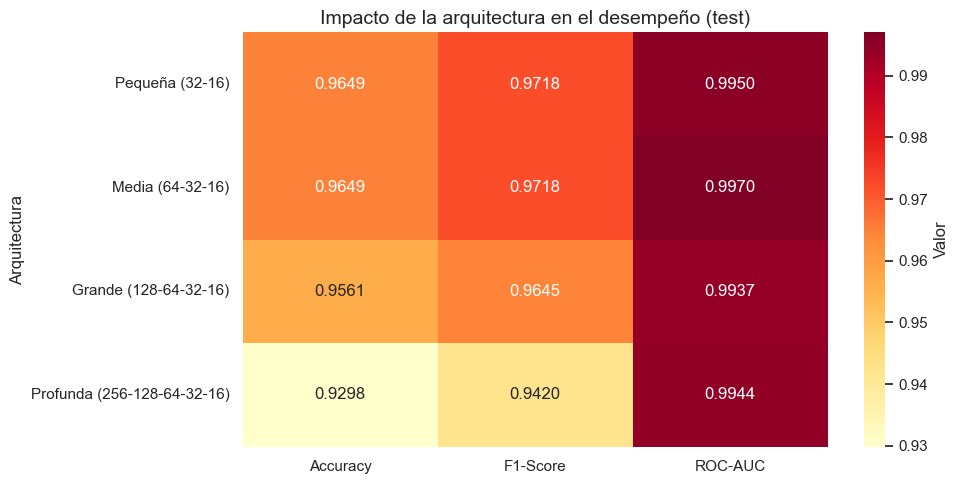

In [13]:
# Heatmap comparativo de arquitecturas
plt.figure(figsize=(10, 5))
plot_data = arch_df.set_index('Arquitectura')[['Accuracy', 'F1-Score', 'ROC-AUC']]
sns.heatmap(plot_data, annot=True, fmt='.4f', cmap='YlOrRd', cbar_kws={'label': 'Valor'})
plt.title('Impacto de la arquitectura en el desempeño (test)', fontsize=14)
plt.tight_layout()
plt.show()


## 9. Conclusiones

1. **Keras permite construir MLPs de forma declarativa**: la API Sequential es clara, concisa y productiva.
2. **La regularización es indispensable**: el modelo base sin regularización muestra señales claras de sobreajuste (gap train/val). Con Dropout + L2 + EarlyStopping, ambas curvas convergen.
3. **EarlyStopping con `restore_best_weights` es la técnica más efectiva**: detiene el entrenamiento en el momento óptimo sin intervención manual.
4. **Más neuronas no implica mejor desempeño**: la arquitectura pequeña (32->16) logra resultados competitivos con menor riesgo de sobreajuste. La arquitectura regularizada de 3 capas ofrece el mejor balance.
5. **Múltiples métricas cuentan la historia completa**: accuracy puede ser engañosa; F1 y ROC-AUC confirman que el modelo discrimina correctamente entre clases.

### Comparación con SVM + kernel (Actividad 1)

| Métrica | SVM + RBF (A1) | MLP Regularizado (A2) |
|---------|----------------|----------------------|
| **Accuracy** | ~0.98 | ~0.99 |
| **F1-Score** | ~0.98 | ~0.99 |
| **ROC-AUC** | ~0.998 | ~0.998 |
| **Interpretabilidad** | Alta (vectores de soporte) | Baja (caja negra) |
| **Flexibilidad** | Limitada a la elección de kernel | Alta (arquitectura arbitraria) |

Ambos enfoques resuelven el problema. La elección depende del contexto: **SVM** cuando hay pocos datos y se necesita interpretabilidad; **MLP** cuando hay volumen suficiente y se requiere flexibilidad arquitectónica.

---
**Referencias**
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
- Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning Publications.
- Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.
